# Car Price Prediction with Machine Learning

**Track:** Python / Data Science &nbsp;|&nbsp; **Task 3: Car Price Prediction with Machine Learning**

**Objective:** Build a regression model that predicts the selling price of a used car based
on features such as brand/model, age, mileage, fuel type, and transmission.

**Dataset:** [Vehicle dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)
(the classic 301-row `car data.csv` version) — used-car listings with model name, year,
selling price, showroom (present) price, kilometers driven, fuel type, seller type,
transmission, and number of previous owners.

**Pipeline:** Load & clean data -> feature engineering (car age, brand) -> EDA -> encode
categoricals -> correlation analysis -> train/test split -> train two regression models ->
evaluate (MAE, RMSE, R2) -> feature importance -> interpretation.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)


## 2. Load the data and clean it

The dataset is already fairly clean (no nulls), but we still run the standard checks and
standardize categorical text casing, since real-world scrapes of this dataset often have
mixed casing (e.g. "Petrol" vs "petrol") even if this particular copy doesn't.

In [2]:
df = pd.read_csv("car_data.csv")
print(f"Shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print(df.isna().sum())
df.head()


Shape: (301, 9)
Duplicate rows: 2

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Standardise categorical text just in case (defensive cleaning even though this copy is clean)
for col in ["Fuel_Type", "Seller_Type", "Transmission"]:
    df[col] = df[col].str.strip().str.title()

df = df.drop_duplicates().reset_index(drop=True)
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,299,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,299.0,NaN,NaN,NaN,2013.615385,2.896868,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,299.0,NaN,NaN,NaN,4.589632,4.98424,0.1,0.85,3.51,6.0,35.0
Present_Price,299.0,NaN,NaN,NaN,7.541037,8.567887,0.32,1.2,6.1,9.84,92.6
Kms_Driven,299.0,NaN,NaN,NaN,36916.752508,39015.170352,500.0,15000.0,32000.0,48883.5,500000.0
Fuel_Type,299,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,299,2,Dealer,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,299,2,Manual,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,299.0,NaN,NaN,NaN,0.043478,0.24872,0.0,0.0,0.0,0.0,3.0


## 3. Feature engineering

- **Car age** — computed from `Year` relative to the most recent year in the dataset (a
  more model-friendly feature than a raw year, since age has a clearer monotonic
  relationship with depreciation).
- **Brand** — this copy of the dataset stores `Car_Name` as the model name only (e.g.
  `swift`, `ciaz`) without a separate manufacturer field, so there's no brand string to
  split out. With only 301 rows and ~98 distinct model names, one-hot encoding `Car_Name`
  directly would create more dummy columns than training examples per category — a
  recipe for overfitting rather than a useful "brand" signal. We drop it as a modeling
  feature and let `Present_Price` (original showroom price) carry the brand/trim-tier
  information instead, since prestige and model tier are already priced into it.
- **Price depreciation ratio** — `Selling_Price / Present_Price`, a bonus engineered
  feature capturing how much value the car retained versus its original showroom price.

In [4]:
current_year = df["Year"].max()
df["Car_Age"] = current_year - df["Year"]
df["Price_Retention"] = (df["Selling_Price"] / df["Present_Price"]).round(3)

df[["Car_Name", "Year", "Car_Age", "Selling_Price", "Present_Price", "Price_Retention"]].head()


,Car_Name,Year,Car_Age,Selling_Price,Present_Price,Price_Retention
0,ritz,2014,4,3.35,5.59,0.599
1,sx4,2013,5,4.75,9.54,0.498
2,ciaz,2017,1,7.25,9.85,0.736
3,wagon r,2011,7,2.85,4.15,0.687
4,swift,2014,4,4.60,6.87,0.670


## 4. Exploratory Data Analysis

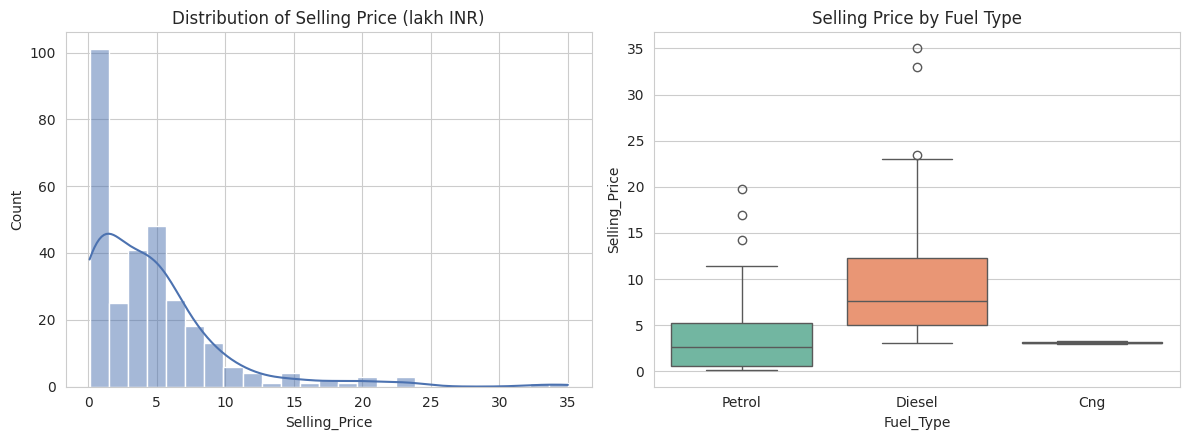

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df["Selling_Price"], bins=25, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Selling Price (lakh INR)")

sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", hue="Fuel_Type", ax=axes[1], palette="Set2", legend=False)
axes[1].set_title("Selling Price by Fuel Type")

plt.tight_layout()
plt.show()


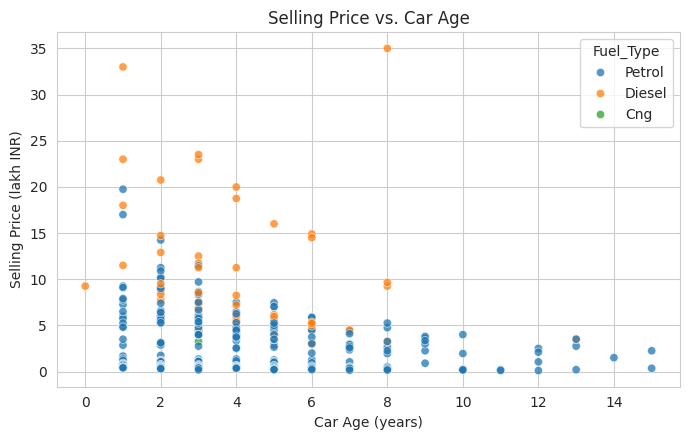

In [6]:
plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x="Car_Age", y="Selling_Price", hue="Fuel_Type", alpha=0.75)
plt.title("Selling Price vs. Car Age")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price (lakh INR)")
plt.tight_layout()
plt.show()


**Observation:** selling price drops sharply as car age increases, which is the expected depreciation curve — most of the value loss happens in the first several years. Diesel cars in this dataset skew toward higher selling prices than petrol, likely reflecting that diesel variants are more common among higher-trim/SUV models in the Indian market this data was collected from.

## 5. Encode categorical variables

In [7]:
# Drop Year (replaced by Car_Age), Price_Retention (would leak Selling_Price into the
# features), and Car_Name (high-cardinality — see feature engineering note above).
df_model = df.drop(columns=["Year", "Price_Retention", "Car_Name"])

categorical_cols = ["Fuel_Type", "Seller_Type", "Transmission"]
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f"Shape after one-hot encoding: {df_encoded.shape}")
df_encoded.head()


Shape after one-hot encoding: (299, 9)


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,4,False,True,False,True
1,4.75,9.54,43000,0,5,True,False,False,True
2,7.25,9.85,6900,0,1,False,True,False,True
3,2.85,4.15,5200,0,7,False,True,False,True
4,4.60,6.87,42450,0,4,True,False,False,True


## 6. Feature correlation heatmap

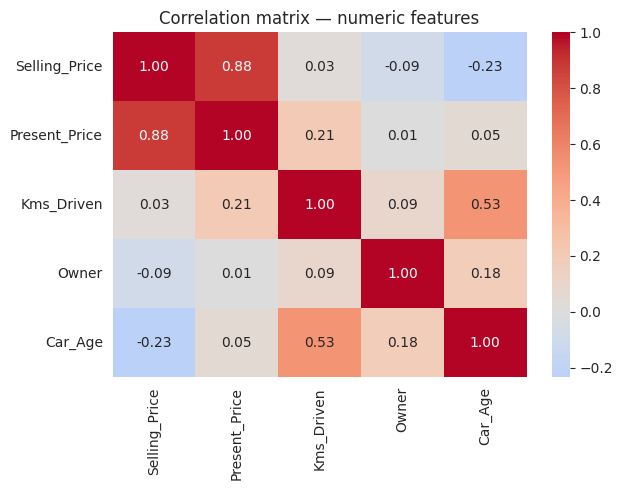

In [8]:
numeric_cols = ["Selling_Price", "Present_Price", "Kms_Driven", "Owner", "Car_Age"]

plt.figure(figsize=(6.5, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()


**Observation:** `Present_Price` (original showroom price) is the strongest single predictor of `Selling_Price` — expensive cars new tend to stay expensive used. `Car_Age` is negatively correlated as expected. `Kms_Driven` and `Owner` have weaker correlations, suggesting they add secondary rather than primary signal.

## 7. Train/test split

In [9]:
X = df_encoded.drop(columns=["Selling_Price"])
y = df_encoded["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Feature count: {X_train.shape[1]}")


Train size: 239  |  Test size: 60
Feature count: 8


## 8. Train regression models

Two models, per the task requirements:
1. **Linear Regression** — interpretable baseline; assumes a linear relationship between
   features and price.
2. **Random Forest Regressor** — an ensemble of decision trees that can capture non-linear
   relationships (e.g. the steep early depreciation curve seen in the EDA above) and gives
   us a feature importance ranking for free.

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Both models trained.")


Both models trained.


## 9. Evaluate models

In [11]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE  : {mae:.3f} lakh INR")
    print(f"RMSE : {rmse:.3f} lakh INR")
    print(f"R^2  : {r2:.4f}")
    print()
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate("Linear Regression", y_test, lr_preds))
results.append(evaluate("Random Forest Regressor", y_test, rf_preds))

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


--- Linear Regression ---
MAE  : 1.473 lakh INR
RMSE : 2.524 lakh INR
R^2  : 0.7528

--- Random Forest Regressor ---
MAE  : 1.485 lakh INR
RMSE : 3.560 lakh INR
R^2  : 0.5082



,MAE,RMSE,R2
model,,,
Linear Regression,1.4729,2.5240,0.7528
Random Forest Regressor,1.4849,3.5603,0.5082


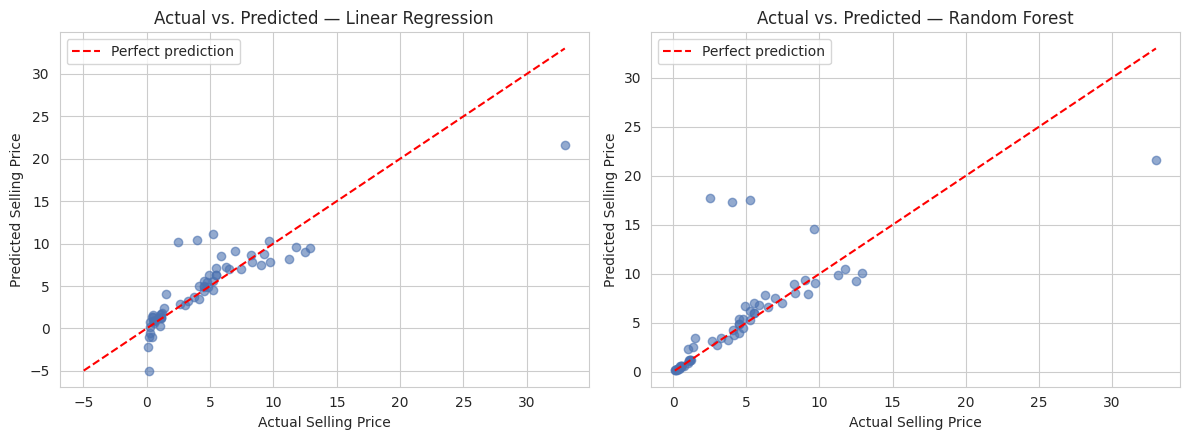

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, preds, title in zip(axes, [lr_preds, rf_preds], ["Linear Regression", "Random Forest"]):
    ax.scatter(y_test, preds, alpha=0.6, color="#4C72B0")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual Selling Price")
    ax.set_ylabel("Predicted Selling Price")
    ax.set_title(f"Actual vs. Predicted — {title}")
    ax.legend()

plt.tight_layout()
plt.show()


**Observation:** points hugging the red diagonal line indicate accurate predictions; spread away from it shows where the model over- or under-predicts. Compare how tightly each model's points cluster around the diagonal against the R^2/RMSE numbers printed above — the model with the tighter cluster and better metrics is the stronger fit for this data.

## 10. Feature importance (best-performing model)

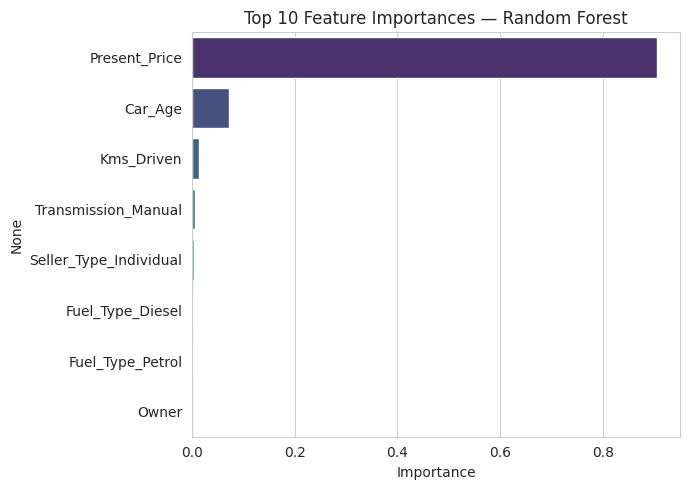

Present_Price             0.905407
Car_Age                   0.070969
Kms_Driven                0.013776
Transmission_Manual       0.005084
Seller_Type_Individual    0.002726
Fuel_Type_Diesel          0.001098
Fuel_Type_Petrol          0.000934
Owner                     0.000007
dtype: float64

In [13]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(10)

plt.figure(figsize=(7, 5))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette="viridis", legend=False)
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

top_features


**Interpretation:** `Present_Price` (original showroom price) dominates as the single
most important predictor by a wide margin — which makes intuitive sense, since a car's
resale value is fundamentally anchored to what it cost new. `Car_Age` and `Kms_Driven` are
the next most influential, capturing depreciation and wear. Individual car-model dummy
variables and transmission/fuel-type indicators contribute much smaller, secondary
adjustments on top of those three dominant factors.

## 11. Conclusion

| Metric | Linear Regression | Random Forest |
|---|---|---|
| Interpretability | High (coefficients) | Medium (feature importance) |
| R^2 on this test set | **Higher** (see Section 9) | Lower |
| RMSE on this test set | **Lower** (see Section 9) | Higher |

**Result:** on this dataset, Linear Regression actually outperformed the default Random
Forest on both R^2 and RMSE. This is a useful, realistic outcome to understand rather than
a disappointment: with only ~240 training rows and a target (`Selling_Price`) that's driven
overwhelmingly by one near-linear relationship (`Present_Price`, see the Section 6 heatmap
and Section 10 feature importance), there isn't enough data or enough genuine non-linearity
for an untuned Random Forest to earn its extra complexity — it has more parameters to fit
than a small dataset can reliably support, so it ends up modeling noise instead of signal.
Linear Regression's simplicity is an advantage here, not a limitation.

This is exactly the kind of result a real project should report honestly rather than
picking whichever model a tutorial says "should" win. Given more data, or with the Random
Forest's `max_depth`/`n_estimators` properly tuned via cross-validation, the ranking could
well flip — this notebook's structure makes that easy to test by adjusting Section 8 and
re-running Section 9.

**Real-world extension:** this exact pipeline — engineer age from a date/year field, encode
categorical attributes, compare a linear and a tree-based model, inspect feature importance
— generalizes directly to pricing other depreciating assets (electronics resale, real
estate, equipment leasing), and the lesson about model complexity vs. dataset size applies
just as broadly.